In [ ]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import shap

In [309]:
# FUNCIONES:

## 1. One hot encoding en una sola linea
def onehotcod(df, col_name):
    # Intanciamos el encoder
    ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=int) #drop='first' elimina la primera columna | sparse_output=False devuelve array
    # Ajustamos y transformamos
    encoded_data = ohe.fit_transform(df[[col_name]]) 
    # Agregamos en df temporal
    nombre_col = ohe.get_feature_names_out([col_name])
    col_dummy = pd.DataFrame(encoded_data, columns=nombre_col)
    # Añadimos al df de estudio
    df=pd.merge(df, col_dummy, on=df.index, how='right').drop(columns=[col_name, "key_0"]).rename(columns={f"{col_name}_yes": f"{col_name}"})
    # Condicional para eliminar nan de las columnas
    if df[col_name].isna().sum()>0:
        df.drop(columns=f"{col_name}_nan")
    return df.columns

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/logistic-regression-project-tutorial/blob/main/README.es.md

Descripción de variables:

- age. Edad del cliente (numérico)

- job. Tipo de trabajo (categórico)

- marital. Estado civil (categórico)

- education. Nivel de educación (categórico)

- default. ¿Tiene crédito actualmente? (categórico)

- housing. ¿Tiene un préstamo de vivienda? (categórico)

- loan. ¿Tiene un préstamo personal? (categórico)

- contact. Tipo de comunicación de contacto (categórico)

- month. Último mes en el que se le ha contactado (categórico)

- day_of_week. Último día en el que se le ha contactado (categórico)

- duration. Duración del contacto previo en segundos (numérico)

- campaign. Número de contactos realizados durante esta campaña al cliente (numérico)

- pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)

- previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)

- poutcome. Resultado de la campaña de marketing anterior (categórico)

- emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico)

- cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico)

- cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico)

- euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico)

- nr.employed. Número de empleados. Indicador trimestral (numérico)

- y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico)

In [310]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [311]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores unicos

In [312]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


## 1.2. Verificar valores duplicados

### 1.2.1. Filas

In [313]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 12 filas duplicadas


In [314]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].T

,1265,1266,12260,12261,14155,14234,16819,16956,18464,18465,...,25183,25217,28476,28477,32505,32516,36950,36951,38255,38281
age,39,39,36,36,27,27,47,47,32,32,...,39,39,24,24,35,35,45,45,71,71
job,blue-collar,blue-collar,retired,retired,technician,technician,technician,technician,technician,technician,...,admin.,admin.,services,services,admin.,admin.,admin.,admin.,retired,retired
marital,married,married,married,married,single,single,divorced,divorced,single,single,...,married,married,single,single,married,married,married,married,single,single
education,basic.6y,basic.6y,unknown,unknown,professional.course,professional.course,high.school,high.school,professional.course,professional.course,...,university.degree,university.degree,high.school,high.school,university.degree,university.degree,university.degree,university.degree,university.degree,university.degree
default,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
housing,no,no,no,no,no,no,yes,yes,yes,yes,...,no,no,yes,yes,yes,yes,no,no,no,no
loan,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
contact,telephone,telephone,telephone,telephone,cellular,cellular,cellular,cellular,cellular,cellular,...,cellular,cellular,cellular,cellular,cellular,cellular,cellular,cellular,telephone,telephone
month,may,may,jul,jul,jul,jul,jul,jul,jul,jul,...,nov,nov,apr,apr,may,may,jul,jul,oct,oct
day_of_week,thu,thu,thu,thu,mon,mon,thu,thu,thu,thu,...,tue,tue,tue,tue,fri,fri,thu,thu,tue,tue


In [315]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


### 1.2.2. Columnas

In [316]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.3. Verificar missing values

### 1.3.1. Datos enmascarados(categoricas)

In [317]:
#Datos enmascarados (variables categoricas)
columnas=df.select_dtypes(include='object').drop(columns="y", axis=1)
for col in columnas:
    print("-"*20)
    print(f"Columna: {col}")
    print("-"*20)
    print(df[col].value_counts(normalize=True)*100)

--------------------
Columna: job
--------------------
job
admin.           25.303575
blue-collar      22.471828
technician       16.366330
services          9.634253
management        7.101224
retired           4.172333
entrepreneur      3.536040
self-employed     3.451039
housemaid         2.574315
unemployed        2.462600
student           2.125024
unknown           0.801438
Name: proportion, dtype: float64
--------------------
Columna: marital
--------------------
marital
married     60.523120
single      28.084321
divorced    11.198271
unknown      0.194288
Name: proportion, dtype: float64
--------------------
Columna: education
--------------------
education
university.degree      29.541480
high.school            23.100835
basic.9y               14.680882
professional.course    12.725860
basic.4y               10.141830
basic.6y                5.563921
unknown                 4.201477
illiterate              0.043715
Name: proportion, dtype: float64
--------------------
Columna

Se aprecia como los valores nulos aparecen como: ``unknown`` y ``nonexistent``

In [318]:
# Reemplazamos y visualizamos categorias anteriores por NaN
df.replace(["unknown", "nonexistent"], np.nan, inplace=True)

### 1.3.2. Datos enmascarados(numericos)

In [319]:
df.select_dtypes(["int64", "float64"]).describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


<Axes: xlabel='pdays', ylabel='Count'>

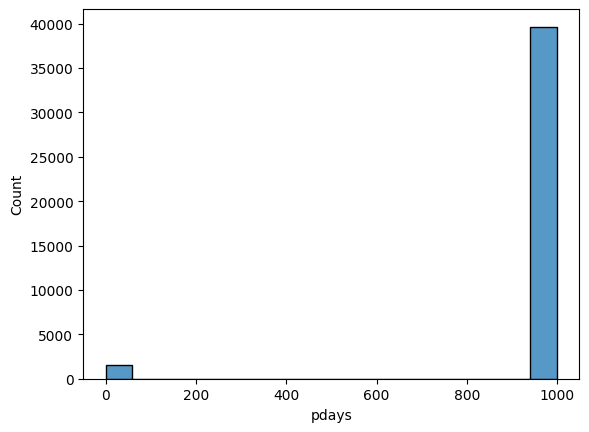

In [320]:
sns.histplot(data=df, x="pdays", bins="auto")

In [321]:
# Reemplazamos y visualizamos categorias anteriores por NaN
df["pdays"].replace(999, np.nan, inplace=True)

C:\Users\jjime\AppData\Local\Temp\ipykernel_16232\164245507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["pdays"].replace(999, np.nan, inplace=True)


### 1.3.3. Visualización

In [322]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

job           0.801438
marital       0.194288
education     4.201477
default      20.876239
housing       2.404313
loan          2.404313
pdays        96.320672
poutcome     86.339130
dtype: float64

[]

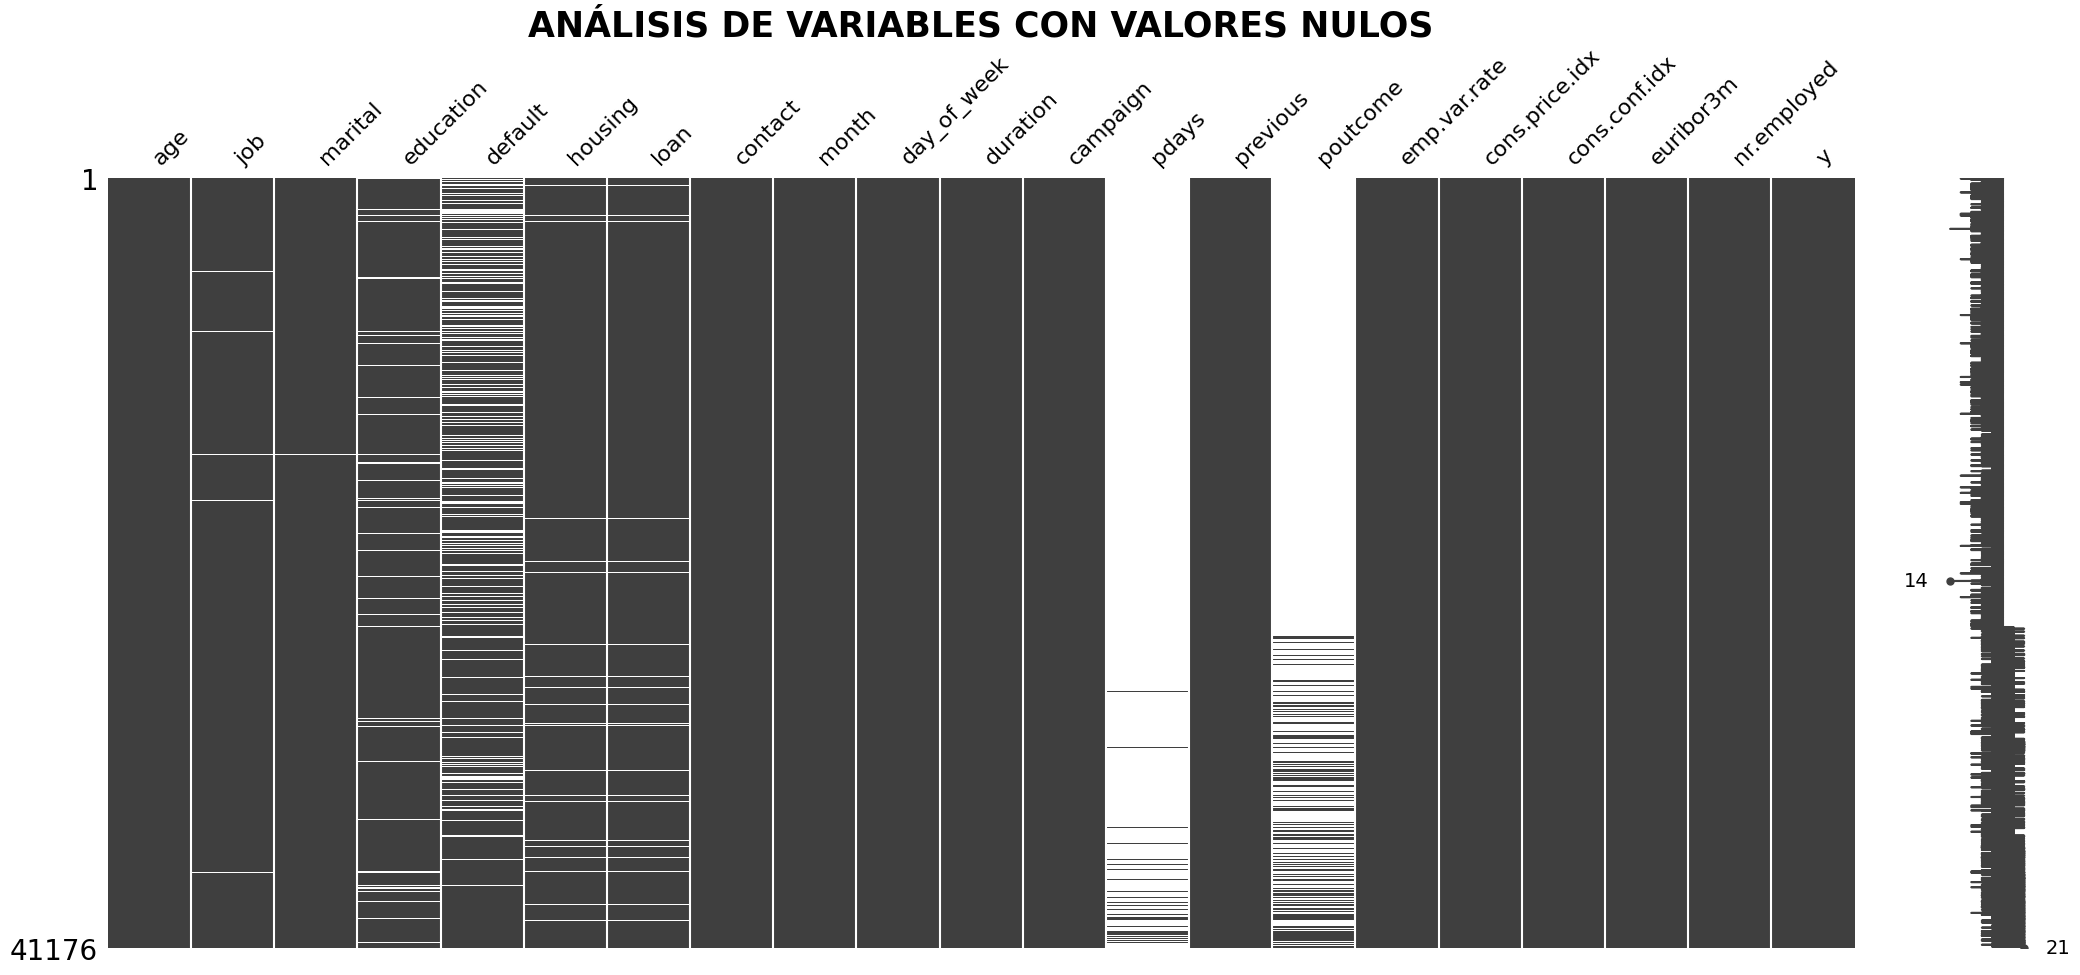

In [323]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

Como no hay columnas con más de un 40% de missing values, los valores faltantes que se observan será imputamos después de hcaer la división Train/Test.

### 1.3.4. Eliminación

Eliminaremos una fila o columna si presenta más de un 40% de sus datos como faltantes.

In [324]:
#Verificamos si hay filas con más de un 40% de missing values
column=df.isna().sum()/len(df)*100
print("No hay filas con muchas variables sin valores" if column[column>40].sum()==0 
      else f"Las columnas {column[column>40].index.to_list()} no aportan información")

Las columnas ['pdays', 'poutcome'] no aportan información


In [325]:
#Verificamos si hay filas con más de un 40% de missing values
filas=df.T.isna().sum()/len(df.T)*100
print("No hay filas con muchas variables sin valores" if filas[filas>40].sum()==0 
      else f"Hay {filas.sum()} filas con variables sin valores")

No hay filas con muchas variables sin valores


In [326]:
df.drop(columns=['pdays', 'poutcome'], axis=1, inplace=True)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,0,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,1.1,93.994,-36.4,4.857,5191.0,no


## 1.4. Codificar variables categoricas

Tipos de categoricas:

- Ordinal (hay orden implicito en los datos)
    - <u>Métodos</u>: ordinal encoding
- Nominal I (no hay orden, baja cardinalidad: 10 categorias)
    - <u>Métodos</u>: one hot encoding
- Nominal II (no hay orden, alta cardinalidad)
    - <u>Métodos</u>: proportion z test

In [327]:
# Visualizamos valores unicos y numero de categorías
for col in df.select_dtypes("object").drop(columns="y"):
    print(f"\n{'='*30}")
    print(f"COLUMNA: {col.upper()}")
    print(f"{'='*30}")
    
    # Valores únicos
    valores = df[col].dropna().unique() # → Elimina los NaN antes de obtener los valores únicos
    print(f"Número de categorías: {len(valores)}")
    print(f"Valores: {valores}\n")  


COLUMNA: JOB
Número de categorías: 11
Valores: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'entrepreneur' 'student']


COLUMNA: MARITAL
Número de categorías: 3
Valores: ['married' 'single' 'divorced']


COLUMNA: EDUCATION
Número de categorías: 7
Valores: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'university.degree' 'illiterate']


COLUMNA: DEFAULT
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: HOUSING
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: LOAN
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: CONTACT
Número de categorías: 2
Valores: ['telephone' 'cellular']


COLUMNA: MONTH
Número de categorías: 10
Valores: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


COLUMNA: DAY_OF_WEEK
Número de categorías: 5
Valores: ['mon' 'tue' 'wed' 'thu' 'fri']



In [328]:
onehot=[]
prop=[]

for col in df.select_dtypes("object").drop(columns="y"):
# Condicional para ordenar variables
    onehot.append(col) if df[col].nunique()<=5 else prop.append(col)  

print(f"Filas con menos de 5 categorias: {onehot}")
print(f"Filas con más de 5 categorias: {prop}")

Filas con menos de 5 categorias: ['marital', 'default', 'housing', 'loan', 'contact', 'day_of_week']
Filas con más de 5 categorias: ['job', 'education', 'month']


### 1.4.1. Menos de 5 categorias

#### A) **Y**

In [329]:
# Llamamos a la función
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=int) # drop='first' elimina una cat | sparse_output=False devuelve array

# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["y"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["y"])
y = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, y, on=df.index, how='right').drop(columns=["y", "key_0"]).rename(columns={"y_yes": "y"})
df["y"]

0        0
1        0
2        0
3        0
4        0
        ..
41171    1
41172    0
41173    0
41174    1
41175    0
Name: y, Length: 41176, dtype: int64

#### B) Marital

[]

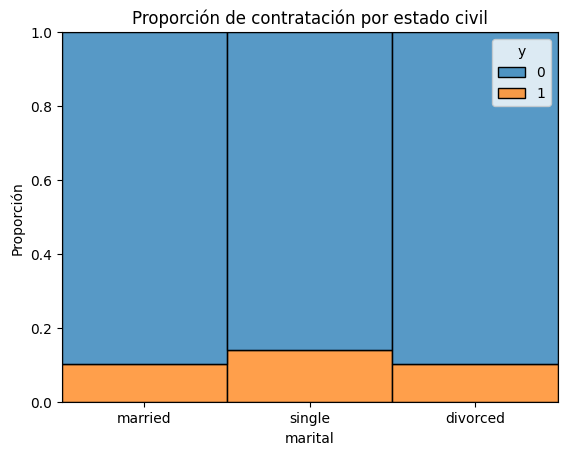

In [330]:
## Representacion
sns.histplot(data=df, x="marital", hue="y", multiple="fill")
plt.title("Proporción de contratación por estado civil")
plt.ylabel("Proporción")
plt.plot()

In [331]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["marital"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["marital"])
marital = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, marital, on=df.index, how='right').drop(columns=["marital", "marital_nan", "key_0"]).rename(columns={"marital_married": "maried", "marital_single": "single"})
df.columns

Index(['age', 'job', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'maried', 'single'],
      dtype='object')

#### C) Default

In [332]:
#Testamos si la variable realmente es significativa
resumen=df.groupby("default")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
default,,,
no,32577,4196,0.128803
yes,3,0,0.000000


In [333]:
# unemployed y admin.
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

50.5424 %


[]

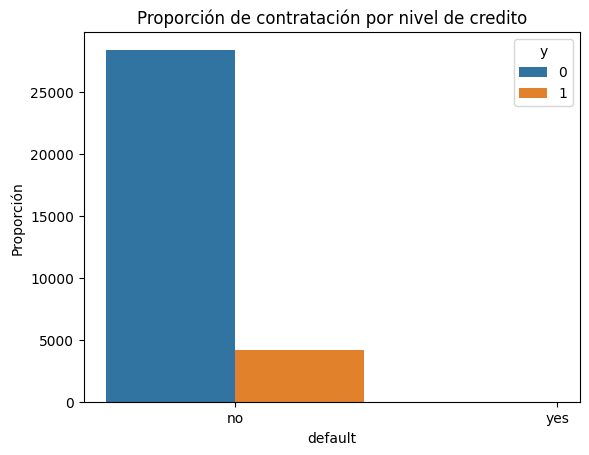

In [334]:
## Representacion
sns.countplot(data=df, x="default", hue="y")
plt.title("Proporción de contratación por nivel de credito")
plt.ylabel("Proporción")
plt.plot()

In [335]:
df.drop(columns="default", axis=1, inplace=True)

#### D) Housing

[]

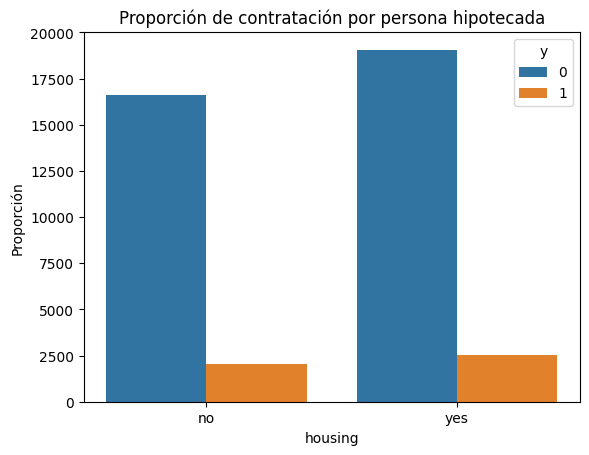

In [336]:
## Representacion
sns.countplot(data=df, x="housing", hue="y")
plt.title("Proporción de contratación por persona hipotecada")
plt.ylabel("Proporción")
plt.plot()

In [337]:
#Testamos si la variable realmente es significativa
resumen=df.groupby("housing")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
housing,,,
yes,21571,2507,0.116221
no,18615,2025,0.108783


In [338]:
# unemployed y admin.
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #A un 5% de significacia, variable importante (H1)

1.8754 %


In [339]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["housing"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["housing"])
housing = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, housing, on=df.index, how='right').drop(columns=["housing", "housing_nan", "key_0"]).rename(columns={"housing_yes": "housing"})
df["housing"].value_counts()

housing
1    21571
0    19605
Name: count, dtype: int64

#### E) Loan

[]

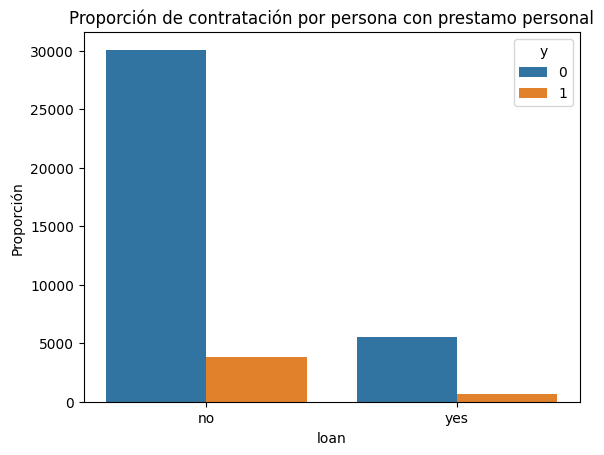

In [340]:
## Representacion
sns.countplot(data=df, x="loan", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [341]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["loan"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["loan"])
loan = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, loan, on=df.index, how='right').drop(columns=["loan", "loan_nan", "key_0"]).rename(columns={"loan_yes": "loan"})
df["loan"].value_counts()

loan
0    34928
1     6248
Name: count, dtype: int64

#### F) Contact

[]

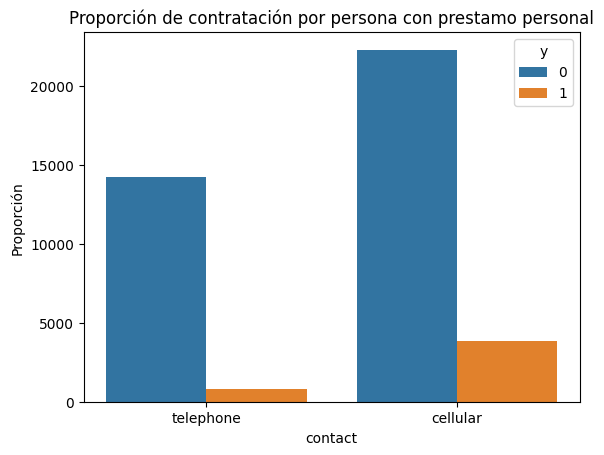

In [342]:
## Representacion
sns.countplot(data=df, x="contact", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [343]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["contact"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["contact"])
contact = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, contact, on=df.index, how='right').drop(columns=["contact", "key_0"]).rename(columns={"contact_telephone": "telephone"})
df["telephone"].value_counts()

telephone
0    26135
1    15041
Name: count, dtype: int64

#### G) Days_of_week

[]

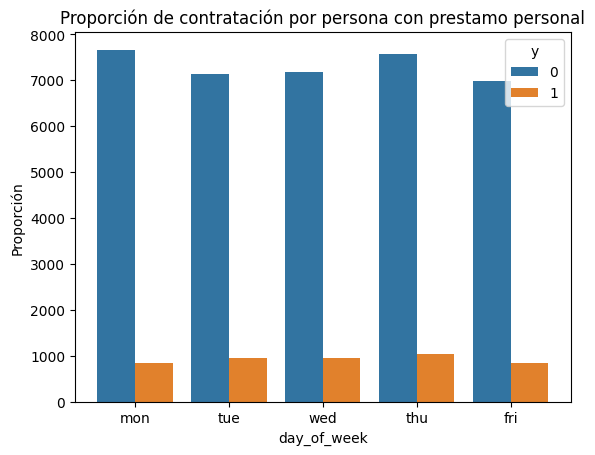

In [344]:
## Representacion
sns.countplot(data=df, x="day_of_week", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [345]:
#Diferencia de proporcion de cotratacion por dia
print(df.groupby("day_of_week")["y"].mean())

#Test chi2
tabla=pd.crosstab(df["day_of_week"], df["y"])
chi2,p,dof,expected=stats.chi2_contingency(tabla)
print("="*30)
print("Hay al menos diferencias de proporcion en un día" if p<0.01 else "No hay diferencia por dia")

day_of_week
fri    0.108101
mon    0.099507
thu    0.121142
tue    0.117858
wed    0.116671
Name: y, dtype: float64
Hay al menos diferencias de proporcion en un día


In [346]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["mon", "tue", "wed", "thu", "fri"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int)

# Transformamos
df["day_of_week"] = ordenc.fit_transform(df[["day_of_week"]])
df["day_of_week"].value_counts().sort_index()

day_of_week
0    8512
1    8086
2    8134
3    8618
4    7826
Name: count, dtype: int64

### 1.4.2. Más de 5 categorias

#### A) Month

[]

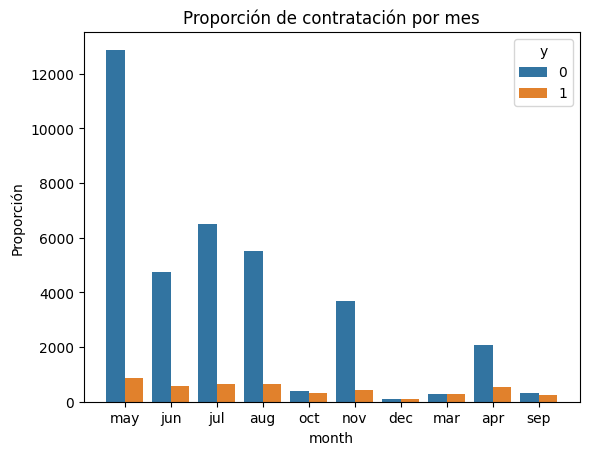

In [347]:
## Representacion
sns.countplot(data=df, x="month", hue="y")
plt.title("Proporción de contratación por mes")
plt.ylabel("Proporción")
plt.plot()

In [348]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int)

# Transformamos
df["month"] = ordenc.fit_transform(df[["month"]])
df["month"].value_counts().sort_index()

month
0      546
1     2631
2    13767
3     5318
4     7169
5     6176
6      570
7      717
8     4100
9      182
Name: count, dtype: int64

#### B) Educación

[]

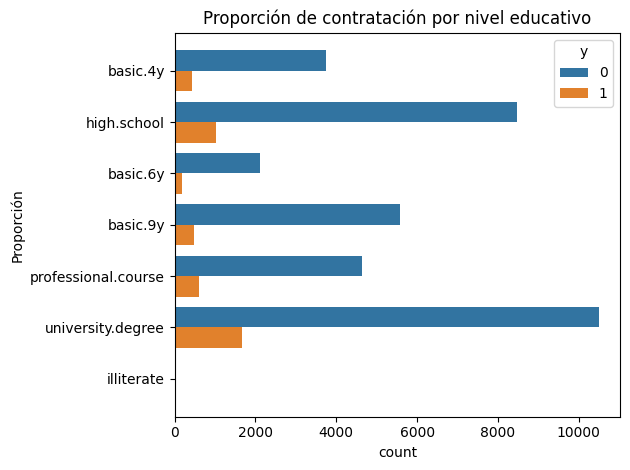

In [349]:
## Representacion
sns.countplot(data=df, y="education", hue="y")
plt.title("Proporción de contratación por nivel educativo")
plt.ylabel("Proporción")
plt.tight_layout()
plt.plot()

In [350]:
resumen=df.groupby("education")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
education,,,
illiterate,18,4,0.222222
university.degree,12164,1669,0.137208
professional.course,5240,595,0.113550
high.school,9512,1031,0.108389
basic.4y,4176,428,0.102490
basic.6y,2291,188,0.082060
basic.9y,6045,473,0.078246


In [351]:
# illiterate y basic 4y
nobs=[resumen["count"].iloc[0], resumen["count"].iloc[4]]
success=[resumen["sum"].iloc[0], resumen["sum"].iloc[4]]
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    df["education"].replace({"illiterate": "basic.4y"}, inplace=True)

9.5397 %


C:\Users\jjime\AppData\Local\Temp\ipykernel_16232\3776088727.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].replace({"illiterate": "basic.4y"}, inplace=True)


In [352]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos
df["education"] = ordenc.fit_transform(df[["education"]])
df["education"].replace({-1: np.nan}, inplace=True)
df["education"].value_counts().sort_index()

C:\Users\jjime\AppData\Local\Temp\ipykernel_16232\1038695132.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].replace({-1: np.nan}, inplace=True)


education
0.0     4194
1.0     2291
2.0     6045
3.0     9512
4.0     5240
5.0    12164
Name: count, dtype: int64

#### C) Job

El hecho de que ``job`` sea una variable nominal con un importante numero de categorias, nos incita a no utilizar one hot encoding y hacer que la base de datos se sobredimensione. De esta forma, vamos a establecer un "orden artifical" con Ordered Target Encoding, aunque para evitar el *data leakage* los valores promedio de ``y`` que utilizaremos para dar orden a las categorías de ``job`` deben ser extraidos de train y copiados a test. Esto hace que test sea lo más imparcial posible.

## 1.5. División Train-Test

In [353]:
#Diviisón de la base de datos
X = df.drop('y',axis=1)
y = df['y']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma
X_train.head()

,age,job,education,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,maried,single,housing,loan,telephone
12346,29,entrepreneur,1.0,4,4,286,3,0,1.4,93.918,-42.7,4.959,5228.1,1,0,1,1,1
8564,50,admin.,5.0,3,2,178,6,0,1.4,94.465,-41.8,4.864,5228.1,0,1,0,0,1
21417,29,admin.,5.0,5,1,103,4,0,1.4,93.444,-36.1,4.963,5228.1,0,1,0,0,0
3315,35,admin.,5.0,2,3,135,1,0,1.1,93.994,-36.4,4.860,5191.0,0,1,0,0,1
33236,40,blue-collar,3.0,2,1,418,1,0,-1.8,92.893,-46.2,1.291,5099.1,0,1,0,0,0


### 1.5.1. Target Encoding

[]

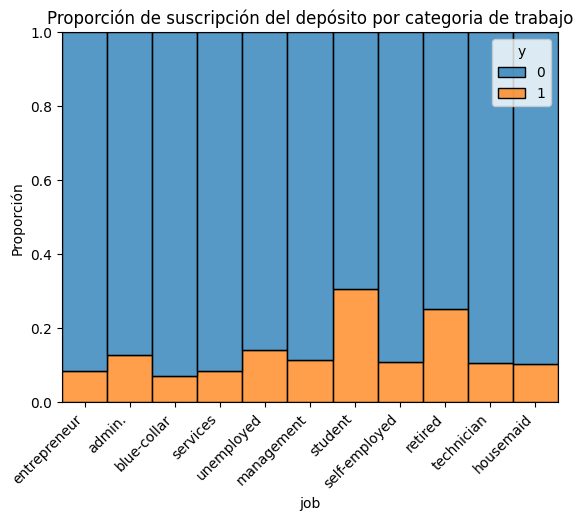

In [354]:
#Representacion gráfica
sns.histplot(x=X_train["job"], hue=y_train, multiple="fill") #multiple=fill expresa en procentajes
plt.title("Proporción de suscripción del depósito por categoria de trabajo")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha='right')
plt.plot()

In [355]:
#Tabla de contingencia
tabla=pd.crosstab(X_train["job"], y_train)

#Test de relación entre variables
chi2,p,dof,expected=stats.chi2_contingency(tabla) #El input para el test es la tabla de contingencias
print(round(p*100,4), "%") #Hay diferencias en al menos una categoria

0.0 %


In [357]:
var_ana=pd.merge(X_train["job"], y_train, on=y_train.index)
resumen=var_ana.groupby("job")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
job,,,
student,682,208,0.304985
retired,1373,345,0.251275
unemployed,791,110,0.139064
admin.,8318,1062,0.127675
management,2362,269,0.113887
self-employed,1095,119,0.108676
technician,5399,563,0.104279
housemaid,868,88,0.101382
entrepreneur,1137,94,0.082674


Categorias con máximo un 1% de diferencia:

- unemployed y admin. 

- management y tetechnician

- housemaid y self-employed

- entrepreneur y services

In [358]:
# unemployed y admin.
nobs=resumen.iloc[2:4,0].to_list()
success=resumen.iloc[2:4,1].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    X_train["job"].replace({"unemployed": "unemploy-admin", "admin.": "unemploy-admin"}, inplace=True)

X_train["job"].unique()

36.0605 %


C:\Users\jjime\AppData\Local\Temp\ipykernel_16232\587409982.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["job"].replace({"unemployed": "unemploy-admin", "admin.": "unemploy-admin"}, inplace=True)


array(['entrepreneur', 'unemploy-admin', 'blue-collar', 'services',
       'management', 'student', 'self-employed', 'retired', 'technician',
       'housemaid', nan], dtype=object)

In [359]:
# management y technician
nobs=resumen.iloc[4:6,0].to_list()
success=resumen.iloc[4:6,1].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    X_train["job"].replace({"management": "manage-tech", "technician": "manage-tech"}, inplace=True)

X_train["job"].unique()

65.1611 %


array(['entrepreneur', 'unemploy-admin', 'blue-collar', 'services',
       'manage-tech', 'student', 'self-employed', 'retired', 'housemaid',
       nan], dtype=object)

In [360]:
# entrepreneur y services
nobs=resumen.iloc[8:10,0].to_list()
success=resumen.iloc[8:10,1].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    X_train["job"].replace({"entrepreneur": "entrepre-service", "entrepreneur": "entrepre-service"}, inplace=True)

X_train["job"].unique()

96.0964 %


array(['entrepre-service', 'unemploy-admin', 'blue-collar', 'services',
       'manage-tech', 'student', 'self-employed', 'retired', 'housemaid',
       nan], dtype=object)

In [363]:
pd.merge(X_train["job"], y_train, on=y_train.index).drop(columns="key_0")

,job,y
0,entrepre-service,0
1,unemploy-admin,0
2,unemploy-admin,0
3,unemploy-admin,0
4,blue-collar,0
...,...,...
32935,blue-collar,0
32936,unemploy-admin,0
32937,retired,0
32938,manage-tech,0


In [364]:
var_ana=pd.merge(X_train["job"], y_train, on=y_train.index).drop(columns="key_0")
var_ana.groupby("job")["y"].mean().sort_values(ascending=False)

job
student             0.304985
retired             0.251275
unemploy-admin      0.128664
self-employed       0.108676
manage-tech         0.107203
housemaid           0.101382
entrepre-service    0.082674
services            0.082209
blue-collar         0.069368
Name: y, dtype: float64

In [ ]:
# Definimos el orden haciendo uso del orden anterior
orden_inducido = ["blue-collar", "services", "entrepre-service", "housemaid", "manage-tech", "self-employed", "unemploy-admin", "retired", "student"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_inducido], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos train
X_train["job"] = ordenc.fit_transform(X_train[["job"]])
X_train["job"].replace({-1: np.nan}, inplace=True)
print(X_train["job"].unique().sort_values())
print("="*35)

#Transformamos test
X_test["job"] = ordenc.fit_transform(X_test[["job"]])
X_test["job"].replace({-1: np.nan}, inplace=True)
print(X_test["job"].unique().sort_values())

[ 2.  6.  0.  1.  4.  8.  5.  7.  3. nan]
[ 7.  0. nan  1.  3.  8.  5.]


C:\Users\jjime\AppData\Local\Temp\ipykernel_16232\130032882.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["job"].replace({-1: np.nan}, inplace=True)
C:\Users\jjime\AppData\Local\Temp\ipykernel_16232\130032882.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

## 1.6. Imputación missing values

De nuevo para evitar el data leakage vamos a rellenar los NaN del Test usando los valores en el Train.

In [375]:
X_train.isna().sum()[X_train.isna().sum()>0]/len(X_train)*100

job          0.834851
education    4.219794
dtype: float64

In [384]:
#Base de datos train
categorical=["job", "education", "month", "day_of_week", "maried", "single", "housing", "loan", "telephone"]
imputer = MissForest(categorical=categorical)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index) #.fit_transform() entrena el modelo y predice los valores faltantes

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [04:59<00:00, 59.99s/it]
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fi

In [385]:
#Base de datos test
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index) #.transform() aplica el modelo anterior en unos nuevos datos

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data instead.
  warnings.warn(f"In version {VERSION}, estimator fitting process "
100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


In [390]:
X_train_imp.isna().sum()[X_train.isna().sum()>0]/len(X_train)*100

job          0.0
education    0.0
dtype: float64

In [389]:
X_test_imp.isna().sum()[X_train.isna().sum()>0]/len(X_test)*100

job          0.0
education    0.0
dtype: float64

## 1.7. Análisis de outliers

In [388]:
X_train_imp.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32940.0,40.038039,10.428596,17.000,32.000,38.000,47.000,98.000
job,32940.0,3.503339,2.512899,0.000,1.000,4.000,6.000,8.000
education,32940.0,3.172556,1.649860,0.000,2.000,3.000,5.000,5.000
month,32940.0,3.612083,2.042961,0.000,2.000,3.000,5.000,9.000
day_of_week,32940.0,1.979053,1.409392,0.000,1.000,2.000,3.000,4.000
duration,32940.0,257.030662,258.127602,0.000,102.000,178.000,319.000,4918.000
campaign,32940.0,2.576290,2.784700,1.000,1.000,2.000,3.000,56.000
previous,32940.0,0.172313,0.494235,0.000,0.000,0.000,0.000,7.000
emp.var.rate,32940.0,0.083400,1.569619,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32940.0,93.576831,0.578718,92.201,93.075,93.749,93.994,94.767


In [392]:
iso = IsolationForest(random_state=123)
df_num = X_train_imp.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_imp)

In [394]:
df_num['outlier_flag'].value_counts(normalize=True)*100

outlier_flag
 1    59.338191
-1    40.661809
Name: proportion, dtype: float64

# **2. SELECCIÓN DE CARACTERÍSTICAS**

## 2.1. Aplicar métodos

### 2.1.1. Feature Importance

Trabajaremos con random forest

In [396]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_imp, y_train)

In [397]:
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100

# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train_imp.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()

In [398]:
df_rf_imp

,feature,rf_importance,rf_importance_acum
5,duration,33.820009,33.820009
11,euribor3m,12.762359,46.582369
0,age,9.933314,56.515682
12,nr.employed,6.173758,62.689440
1,job,4.760024,67.449464
6,campaign,4.494817,71.944282
4,day_of_week,4.280645,76.224927
2,education,4.125335,80.350262
8,emp.var.rate,2.919863,83.270125
10,cons.conf.idx,2.824366,86.094491


### 2.1.2. Shuffle Importance

In [402]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imp, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBClassifier(objective='binary:logistic', random_state=42).fit(X_train1, y_train1)

In [ ]:
# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc')
## Extraemos los valores a un df
df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
5,duration,24.261395
8,emp.var.rate,12.361112
11,euribor3m,2.033889
12,nr.employed,1.898918
9,cons.price.idx,1.240511
3,month,0.633886
17,telephone,0.391339
4,day_of_week,0.356588
0,age,0.243111
6,campaign,0.205557


### 2.1.3. SHAP

In [410]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train1, y_train1)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

 97%|=================== | 6370/6588 [00:34<00:01]       

In [414]:
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
5,duration,34.776402
8,emp.var.rate,25.900777
11,euribor3m,10.244055
12,nr.employed,7.395100
3,month,5.495243
9,cons.price.idx,3.681744
17,telephone,3.060696
10,cons.conf.idx,1.897116
6,campaign,1.710120
4,day_of_week,1.544808


## 2.2. Seleccionar variables

In [427]:
#Añadimos resultados a un único df
df_importances = (
    df_rf_imp.drop(columns="rf_importance_acum")
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Hallamos la media para poder comparar
df_importances['importancia_promedio'] = df_importances[['rf_importance', 'perm_imp', 'shap_imp']].mean(axis=1)
df_importances.sort_values('importancia_promedio', ascending=False)

,feature,rf_importance,perm_imp,shap_imp,importancia_promedio
5,duration,33.820009,24.261395,34.776402,30.952602
7,emp.var.rate,2.919863,12.361112,25.900777,13.727251
8,euribor3m,12.762359,2.033889,10.244055,8.346768
14,nr.employed,6.173758,1.898918,7.395100,5.155925
0,age,9.933314,0.243111,1.428582,3.868335
13,month,1.975854,0.633886,5.495243,2.701661
3,cons.price.idx,2.546487,1.240511,3.681744,2.489580
1,campaign,4.494817,0.205557,1.710120,2.136831
4,day_of_week,4.280645,0.356588,1.544808,2.060680
10,job,4.760024,0.034359,0.660914,1.818432


In [422]:
df["duration"].value_counts()

duration
90      170
85      170
136     168
73      167
124     163
       ... 
2055      1
1962      1
1104      1
1551      1
1580      1
Name: count, Length: 1544, dtype: int64

## 2.3. Comprobar vif y correlaciones